## 1. Импорты, seed и устройство

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
import time
from collections import defaultdict

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ARTIFACTS_DIR = 'artifacts'
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Артефакты будут сохранены в {ARTIFACTS_DIR}")

Using device: cpu
Артефакты будут сохранены в artifacts


## 2. Данные и DataLoader

In [27]:
dataset_name = 'EMNIST'

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = torchvision.datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_set = torchvision.datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

total_train = len(train_full)
indices = list(range(total_train))
np.random.shuffle(indices)
split = int(0.8 * total_train)
train_idx, val_idx = indices[:split], indices[split:]

train_set = Subset(train_full, train_idx)
val_set = Subset(train_full, val_idx)

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_set)}, Val size: {len(val_set)}, Test size: {len(test_set)}")
x, y = next(iter(train_loader))
print(f"Batch x shape: {x.shape}, y shape: {y.shape}")
print(f"x min: {x.min():.3f}, max: {x.max():.3f}")
print(f"Количество классов: {len(train_full.classes)}")

100%|██████████| 562M/562M [09:00<00:00, 1.04MB/s] 


Train size: 90240, Val size: 22560, Test size: 18800
Batch x shape: torch.Size([64, 1, 28, 28]), y shape: torch.Size([64])
x min: -1.000, max: 1.000
Количество классов: 47


## 3. Базовая модель MLP и функции обучения

In [28]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[256, 128], output_size=47,
                 dropout_prob=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        layers.append(nn.Flatten())
        prev = input_size
        for hidden in hidden_sizes:
            layers.append(nn.Linear(prev, hidden))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            if dropout_prob > 0:
                layers.append(nn.Dropout(dropout_prob))
            prev = hidden
        layers.append(nn.Linear(prev, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## 4. Эксперименты

In [29]:
experiments = {
    'E1': {
        'model': {'hidden_sizes': [256, 128], 'dropout_prob': 0.0, 'use_batchnorm': False},
        'optimizer': 'Adam',
        'lr': 0.001,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs': 15,
        'early_stopping': False
    },
    'E2': {
        'model': {'hidden_sizes': [256, 128], 'dropout_prob': 0.3, 'use_batchnorm': False},
        'optimizer': 'Adam',
        'lr': 0.001,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs': 15,
        'early_stopping': False
    },
    'E3': {
        'model': {'hidden_sizes': [256, 128], 'dropout_prob': 0.0, 'use_batchnorm': True},
        'optimizer': 'Adam',
        'lr': 0.001,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs': 15,
        'early_stopping': False
    },
    'E4': {
        'model': {'hidden_sizes': [256, 128], 'dropout_prob': 0.3, 'use_batchnorm': True},
        'optimizer': 'Adam',
        'lr': 0.001,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs': 15,
        'early_stopping': True,
        'patience': 4
    },
    'O1': {
        'model': {'hidden_sizes': [256, 128], 'dropout_prob': 0.3, 'use_batchnorm': True},
        'optimizer': 'Adam',
        'lr': 0.1,     
        'weight_decay': 0.0,
        'momentum': None,
        'epochs': 8,
        'early_stopping': False
    },
    'O2': {
        'model': {'hidden_sizes': [256, 128], 'dropout_prob': 0.3, 'use_batchnorm': True},
        'optimizer': 'Adam',
        'lr': 1e-5,   
        'weight_decay': 0.0,
        'momentum': None,
        'epochs': 8,
        'early_stopping': False
    },
    'O3': {
        'model': {'hidden_sizes': [256, 128], 'dropout_prob': 0.3, 'use_batchnorm': True},
        'optimizer': 'SGD',
        'lr': 0.01,
        'weight_decay': 1e-4,
        'momentum': 0.9,
        'epochs': 15,
        'early_stopping': False
    }
}

def run_experiment(exp_id, config):
    print(f"\n--- Запуск эксперимента {exp_id} ---")
    model = MLP(**config['model']).to(device)
    
    if config['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    elif config['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], 
                              momentum=config['momentum'], weight_decay=config['weight_decay'])
    else:
        raise ValueError("Unknown optimizer")
    
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0
    epochs_trained = 0
    
    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch:2d}: Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        
        if config['early_stopping']:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch
                patience_counter = 0
                if exp_id == 'E4':
                    torch.save(model.state_dict(), os.path.join(ARTIFACTS_DIR, 'best_model.pt'))
            else:
                patience_counter += 1
                if patience_counter >= config['patience']:
                    print(f"Early stopping at epoch {epoch}")
                    break
        else:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch
    
    epochs_trained = epoch 
    
    if exp_id == 'E4':
        best_config = {
            'dataset': dataset_name,
            'seed': seed,
            'model': config['model'],
            'training': {k: v for k, v in config.items() if k != 'model'},
            'best_val_accuracy': best_val_acc,
            'best_epoch': best_epoch
        }
        with open(os.path.join(ARTIFACTS_DIR, 'best_config.json'), 'w') as f:
            json.dump(best_config, f, indent=4)
    
    best_val_loss = history['val_loss'][best_epoch-1] if best_epoch > 0 else None
    return history, best_val_acc, best_val_loss

## 5. Запуск экспериментов и сбор результатов

In [30]:
results_rows = []
histories = {}

for exp_id, config in experiments.items():
    history, best_val_acc, best_val_loss = run_experiment(exp_id, config)
    histories[exp_id] = history
    
    model_summary = (f"{config['model']['hidden_sizes']} "
                     f"{'ReLU'}, "
                     f"{'dropout='+str(config['model']['dropout_prob']) if config['model']['dropout_prob']>0 else 'no dropout'}, "
                     f"{'BN' if config['model']['use_batchnorm'] else 'no BN'}")
    
    row = {
        'experiment_id': exp_id,
        'dataset': dataset_name,
        'seed': seed,
        'model_summary': model_summary,
        'optimizer': config['optimizer'],
        'lr': config['lr'],
        'momentum': config['momentum'] if config['momentum'] is not None else '',
        'weight_decay': config['weight_decay'],
        'epochs_trained': len(history['train_loss']),
        'best_val_accuracy': best_val_acc,
        'best_val_loss': best_val_loss
    }
    results_rows.append(row)

df = pd.DataFrame(results_rows)
df.to_csv(os.path.join(ARTIFACTS_DIR, 'runs.csv'), index=False)
print("\nРезультаты сохранены в artifacts/runs.csv")


--- Запуск эксперимента E1 ---
Epoch  1: Train Loss: 1.2052, Acc: 0.6485 | Val Loss: 0.8051, Acc: 0.7535
Epoch  2: Train Loss: 0.6907, Acc: 0.7791 | Val Loss: 0.6674, Acc: 0.7828
Epoch  3: Train Loss: 0.5871, Acc: 0.8076 | Val Loss: 0.5933, Acc: 0.8111
Epoch  4: Train Loss: 0.5322, Acc: 0.8208 | Val Loss: 0.5733, Acc: 0.8117
Epoch  5: Train Loss: 0.4920, Acc: 0.8322 | Val Loss: 0.5552, Acc: 0.8184
Epoch  6: Train Loss: 0.4665, Acc: 0.8377 | Val Loss: 0.5427, Acc: 0.8229
Epoch  7: Train Loss: 0.4396, Acc: 0.8466 | Val Loss: 0.5527, Acc: 0.8233
Epoch  8: Train Loss: 0.4221, Acc: 0.8501 | Val Loss: 0.5500, Acc: 0.8224
Epoch  9: Train Loss: 0.4081, Acc: 0.8532 | Val Loss: 0.5503, Acc: 0.8245
Epoch 10: Train Loss: 0.3895, Acc: 0.8592 | Val Loss: 0.5343, Acc: 0.8302
Epoch 11: Train Loss: 0.3786, Acc: 0.8622 | Val Loss: 0.5474, Acc: 0.8303
Epoch 12: Train Loss: 0.3641, Acc: 0.8657 | Val Loss: 0.5302, Acc: 0.8338
Epoch 13: Train Loss: 0.3586, Acc: 0.8657 | Val Loss: 0.5401, Acc: 0.8322
Epoch 

## 6. Графики

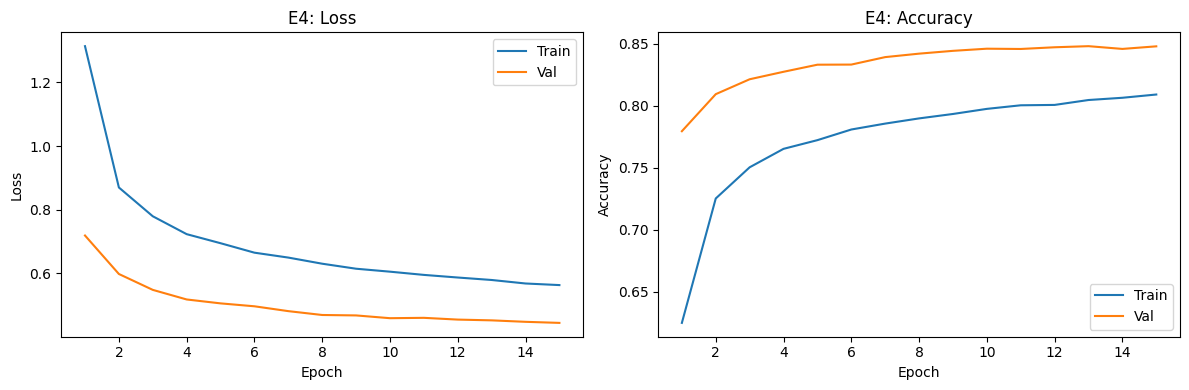

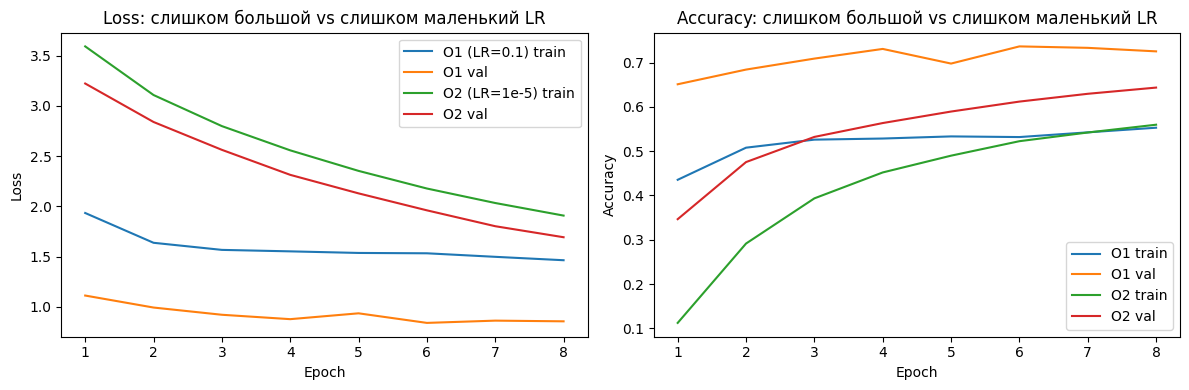

In [31]:
history_e4 = histories['E4']
epochs_e4 = range(1, len(history_e4['train_loss'])+1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_e4, history_e4['train_loss'], label='Train')
plt.plot(epochs_e4, history_e4['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('E4: Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_e4, history_e4['train_acc'], label='Train')
plt.plot(epochs_e4, history_e4['val_acc'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('E4: Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'curves_best.png'), dpi=150)
plt.show()

history_o1 = histories['O1']
history_o2 = histories['O2']
epochs_o1 = range(1, len(history_o1['train_loss'])+1)
epochs_o2 = range(1, len(history_o2['train_loss'])+1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_o1, history_o1['train_loss'], label='O1 (LR=0.1) train')
plt.plot(epochs_o1, history_o1['val_loss'], label='O1 val')
plt.plot(epochs_o2, history_o2['train_loss'], label='O2 (LR=1e-5) train')
plt.plot(epochs_o2, history_o2['val_loss'], label='O2 val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss: слишком большой vs слишком маленький LR')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_o1, history_o1['train_acc'], label='O1 train')
plt.plot(epochs_o1, history_o1['val_acc'], label='O1 val')
plt.plot(epochs_o2, history_o2['train_acc'], label='O2 train')
plt.plot(epochs_o2, history_o2['val_acc'], label='O2 val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy: слишком большой vs слишком маленький LR')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'curves_lr_extremes.png'), dpi=150)
plt.show()

## 7. Финальная оценка лучшей модели на тесте

In [32]:
best_model = MLP(**experiments['E4']['model']).to(device)
best_model.load_state_dict(torch.load(os.path.join(ARTIFACTS_DIR, 'best_model.pt')))
test_loss, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss())
print(f"Лучшая модель (E4) на тесте: Loss = {test_loss:.4f}, Accuracy = {test_acc:.4f}")
with open(os.path.join(ARTIFACTS_DIR, 'best_config.json'), 'r') as f:
    best_conf = json.load(f)
best_conf['test_accuracy'] = test_acc
best_conf['test_loss'] = test_loss
with open(os.path.join(ARTIFACTS_DIR, 'best_config.json'), 'w') as f:
    json.dump(best_conf, f, indent=4)

Лучшая модель (E4) на тесте: Loss = 0.4700, Accuracy = 0.8432
